In [19]:
# Third party packages.
import os

import pandas as pd             # Data handling
import polars as pl             # Data handling ('Blazingly fast DataFrames'), alternative to Pandas.
import polars.selectors as cs   # Select columns of particular type.
import numpy as np              # Numeric calculations
import pickle                   # Save and load data
import seaborn as sns           # Visualize data
import matplotlib.pyplot as plt # Visualize data

from sklearn.model_selection    import train_test_split     # Split data
from sklearn.preprocessing      import StandardScaler       # Scale data
from sklearn.linear_model       import LinearRegression     # Linear regression
from sklearn.linear_model       import LassoCV              # Lasso regression
from sklearn.preprocessing      import OneHotEncoder        # One hot encoding
from sklearn.neighbors          import KNeighborsRegressor  # KNN regression
from sklearn.model_selection    import GridSearchCV         # Grid search

from scipy.stats import pearsonr # Correlation

In [43]:
# Load datasets
df_ogd =  pl.read_parquet(f'../Experiment/Knee/prepared_datasets/pipeline1_test.parquet')
df_mm = pl.read_parquet(f'../Experiment/Knee/prepared_datasets/pipeline2_median_mode_test.parquet')
df_mice = pl.read_parquet(f'../Experiment/Knee/prepared_datasets/pipeline3_mice_test.parquet')

In [45]:
df_ogd.columns

['Revision Flag',
 'Age Band',
 'Gender',
 'Pre-Op Q Assisted',
 'Pre-Op Q Symptom Period',
 'Pre-Op Q Previous Surgery',
 'Pre-Op Q Living Arrangements',
 'Pre-Op Q Disability',
 'Heart Disease',
 'High Bp',
 'Stroke',
 'Circulation',
 'Lung Disease',
 'Diabetes',
 'Kidney Disease',
 'Nervous System',
 'Liver Disease',
 'Cancer',
 'Depression',
 'Arthritis',
 'Pre-Op Q Mobility',
 'Pre-Op Q Self-Care',
 'Pre-Op Q Activity',
 'Pre-Op Q Discomfort',
 'Pre-Op Q Anxiety',
 'Knee Replacement Pre-Op Q Pain',
 'Knee Replacement Pre-Op Q Night Pain',
 'Knee Replacement Pre-Op Q Washing',
 'Knee Replacement Pre-Op Q Transport',
 'Knee Replacement Pre-Op Q Walking',
 'Knee Replacement Pre-Op Q Standing',
 'Knee Replacement Pre-Op Q Limping',
 'Knee Replacement Pre-Op Q Kneeling',
 'Knee Replacement Pre-Op Q Work',
 'Knee Replacement Pre-Op Q Confidence',
 'Knee Replacement Pre-Op Q Shopping',
 'Knee Replacement Pre-Op Q Stairs',
 'health_gain',
 '__index_level_0__']

In [46]:
# Variables to compare
vars_to_compare = [
    'health_gain',
    'Age Band',
    'Gender',
    'Revision Flag',
    # Pre-Op Q variables
    'Pre-Op Q Assisted','Pre-Op Q Assisted By','Pre-Op Q Symptom Period',
    'Pre-Op Q Previous Surgery','Pre-Op Q Living Arrangements','Pre-Op Q Disability',
    'Pre-Op Q Mobility','Pre-Op Q Self-Care','Pre-Op Q Activity',
    'Pre-Op Q Discomfort','Pre-Op Q Anxiety',
    # Knee-specific Pre-Op Q variables
    'Knee Replacement Pre-Op Q Pain','Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing','Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking','Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping','Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work','Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping','Knee Replacement Pre-Op Q Stairs',
    # Comorbidities
    'Heart Disease','High Bp','Stroke','Circulation','Lung Disease','Diabetes',
    'Kidney Disease','Nervous System','Liver Disease','Cancer','Depression','Arthritis'
]

# Select only relevant columns
df_ogd  = df_ogd.select(vars_to_compare)
df_mm   = df_mm.select(vars_to_compare)
df_mice = df_mice.select(vars_to_compare)

ColumnNotFoundError: unable to find column "Pre-Op Q Assisted By"; valid columns: ["Revision Flag", "Age Band", "Gender", "Pre-Op Q Assisted", "Pre-Op Q Symptom Period", "Pre-Op Q Previous Surgery", "Pre-Op Q Living Arrangements", "Pre-Op Q Disability", "Heart Disease", "High Bp", "Stroke", "Circulation", "Lung Disease", "Diabetes", "Kidney Disease", "Nervous System", "Liver Disease", "Cancer", "Depression", "Arthritis", "Pre-Op Q Mobility", "Pre-Op Q Self-Care", "Pre-Op Q Activity", "Pre-Op Q Discomfort", "Pre-Op Q Anxiety", "Knee Replacement Pre-Op Q Pain", "Knee Replacement Pre-Op Q Night Pain", "Knee Replacement Pre-Op Q Washing", "Knee Replacement Pre-Op Q Transport", "Knee Replacement Pre-Op Q Walking", "Knee Replacement Pre-Op Q Standing", "Knee Replacement Pre-Op Q Limping", "Knee Replacement Pre-Op Q Kneeling", "Knee Replacement Pre-Op Q Work", "Knee Replacement Pre-Op Q Confidence", "Knee Replacement Pre-Op Q Shopping", "Knee Replacement Pre-Op Q Stairs", "health_gain", "__in

In [ ]:
# --- Missingness comparison ---

# Count missing values in each dataset
missing_ogd = (
    df_ogd.null_count()
    .melt(variable_name="variable", value_name="missing_ogd")
)

missing_mm = (
    df_mm.null_count()
    .melt(variable_name="variable", value_name="missing_mm")
)

missing_mice = (
    df_mice.null_count()
    .melt(variable_name="variable", value_name="missing_mice")
)

# Join results side-by-side
missing_compare = missing_ogd.join(missing_mm, on="variable").join(missing_mice, on="variable")

print("=== Missingness Comparison ===")
print(missing_compare)

# --- Scrollable table ---
from IPython.display import HTML

HTML(f"""
<div style="height:400px; overflow:auto; border:1px solid #ccc; padding:10px;">
    {missing_compare.to_pandas().to_html(index=False)}
</div>
""")


C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\1815470690.py:6: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="variable", value_name="missing_ogd")
C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\1815470690.py:11: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="variable", value_name="missing_mm")
C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\1815470690.py:16: DeprecationWarning: `DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`
  .melt(variable_name="variable", value_name="missing_mice")


=== Missingness Comparison ===
shape: (39, 4)
┌───────────────────┬─────────────┬────────────┬──────────────┐
│ variable          ┆ missing_ogd ┆ missing_mm ┆ missing_mice │
│ ---               ┆ ---         ┆ ---        ┆ ---          │
│ str               ┆ u32         ┆ u32        ┆ u32          │
╞═══════════════════╪═════════════╪════════════╪══════════════╡
│ health_gain       ┆ 0           ┆ 0          ┆ 0            │
│ Age Band          ┆ 0           ┆ 0          ┆ 0            │
│ Gender            ┆ 0           ┆ 0          ┆ 0            │
│ Revision Flag     ┆ 0           ┆ 0          ┆ 0            │
│ Pre-Op Q Assisted ┆ 0           ┆ 0          ┆ 0            │
│ …                 ┆ …           ┆ …          ┆ …            │
│ Nervous System    ┆ 0           ┆ 0          ┆ 0            │
│ Liver Disease     ┆ 0           ┆ 0          ┆ 0            │
│ Cancer            ┆ 0           ┆ 0          ┆ 0            │
│ Depression        ┆ 0           ┆ 0          ┆ 0        

variable,missing_ogd,missing_mm,missing_mice
health_gain,0,0,0
Age Band,0,0,0
Gender,0,0,0
Revision Flag,0,0,0
Pre-Op Q Assisted,0,0,0
Pre-Op Q Assisted By,0,0,0
Pre-Op Q Symptom Period,0,0,0
Pre-Op Q Previous Surgery,0,0,0
Pre-Op Q Living Arrangements,0,0,0
Pre-Op Q Disability,0,0,0


In [ ]:
# --- Identify numeric and categorical variables ---
numeric_vars = [
    'health_gain',
    'Pre-Op Q Assisted','Pre-Op Q Assisted By','Pre-Op Q Symptom Period',
    'Pre-Op Q Previous Surgery','Pre-Op Q Living Arrangements','Pre-Op Q Disability',
    'Pre-Op Q Mobility','Pre-Op Q Self-Care','Pre-Op Q Activity',
    'Pre-Op Q Discomfort','Pre-Op Q Anxiety',
    'Knee Replacement Pre-Op Q Pain','Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing','Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking','Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping','Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work','Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping','Knee Replacement Pre-Op Q Stairs'
]

categorical_vars = [
    'Age Band','Gender','Revision Flag',
    'Heart Disease','High Bp','Stroke','Circulation','Lung Disease','Diabetes',
    'Kidney Disease','Nervous System','Liver Disease','Cancer','Depression','Arthritis'
]

In [ ]:
# --- Summary statistics for numeric variables ---

stats_ogd = df_ogd.select(
    [
        pl.col(v).mean().alias(f"{v}_mean_ogd")
        for v in numeric_vars
    ] + [
        pl.col(v).std().alias(f"{v}_std_ogd")
        for v in numeric_vars
    ] + [
        pl.col(v).median().alias(f"{v}_median_ogd")
        for v in numeric_vars
    ]
)

stats_mm = df_mm.select(
    [
        pl.col(v).mean().alias(f"{v}_mean_mm")
        for v in numeric_vars
    ] + [
        pl.col(v).std().alias(f"{v}_std_mm")
        for v in numeric_vars
    ] + [
        pl.col(v).median().alias(f"{v}_median_mm")
        for v in numeric_vars
    ]
)

stats_mice = df_mice.select(
    [
        pl.col(v).mean().alias(f"{v}_mean_mice")
        for v in numeric_vars
    ] + [
        pl.col(v).std().alias(f"{v}_std_mice")
        for v in numeric_vars
    ] + [
        pl.col(v).median().alias(f"{v}_median_mice")
        for v in numeric_vars
    ]
)

print("=== Numeric Summary Statistics: OGD ===")
print(stats_ogd)

print("=== Numeric Summary Statistics: MM ===")
print(stats_mm)

print("=== Numeric Summary Statistics: MICE ===")
print(stats_mice)


=== Numeric Summary Statistics: OGD ===
shape: (1, 72)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ health_ga ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ … ┆ Knee Repl ┆ Knee Repl ┆ Knee Repl ┆ Knee Rep │
│ in_mean_o ┆ Assisted_ ┆ Assisted  ┆ Symptom   ┆   ┆ acement   ┆ acement   ┆ acement   ┆ lacement │
│ gd        ┆ mean_ogd  ┆ By_mean_o ┆ Period_me ┆   ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q │
│ ---       ┆ ---       ┆ gd        ┆ an_o…     ┆   ┆ Work…     ┆ Conf…     ┆ Shop…     ┆ Stai…    │
│ f32       ┆ f64       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 16.934542 ┆ 1.853397  ┆ 1.0       ┆ 2.60679   ┆ … ┆ 1.0       ┆ 2.0       ┆ 2.0       ┆ 2.0      │
└───────────┴───────────┴───────────

In [ ]:
# --- Simple value counts for categorical variables ---

for col in categorical_vars:
    print(f"\n=== Value Counts for {col} ===")
    
    print("OGD:")
    print(df_ogd[col].value_counts())
    
    print("MM:")
    print(df_mm[col].value_counts())
    
    print("MICE:")
    print(df_mice[col].value_counts())


=== Value Counts for Age Band ===
OGD:
shape: (6, 2)
┌──────────┬───────┐
│ Age Band ┆ count │
│ ---      ┆ ---   │
│ f64      ┆ u32   │
╞══════════╪═══════╡
│ 6.0      ┆ 5     │
│ 3.0      ┆ 7778  │
│ 2.0      ┆ 2288  │
│ 4.0      ┆ 9130  │
│ 5.0      ┆ 2500  │
│ 1.0      ┆ 38    │
└──────────┴───────┘
MM:
shape: (6, 2)
┌──────────┬───────┐
│ Age Band ┆ count │
│ ---      ┆ ---   │
│ f64      ┆ u32   │
╞══════════╪═══════╡
│ 4.0      ┆ 12102 │
│ 6.0      ┆ 4     │
│ 3.0      ┆ 8501  │
│ 1.0      ┆ 46    │
│ 5.0      ┆ 2955  │
│ 2.0      ┆ 2583  │
└──────────┴───────┘
MICE:
shape: (6, 2)
┌──────────┬───────┐
│ Age Band ┆ count │
│ ---      ┆ ---   │
│ f64      ┆ u32   │
╞══════════╪═══════╡
│ 6.0      ┆ 4     │
│ 1.0      ┆ 46    │
│ 3.0      ┆ 9487  │
│ 5.0      ┆ 2959  │
│ 4.0      ┆ 11112 │
│ 2.0      ┆ 2583  │
└──────────┴───────┘

=== Value Counts for Gender ===
OGD:
shape: (2, 2)
┌────────┬───────┐
│ Gender ┆ count │
│ ---    ┆ ---   │
│ f64    ┆ u32   │
╞════════╪═══════╡
│ 1.0

=== Summary Statistics: OGD ===
shape: (1, 120)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ health_ga ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ … ┆ Knee Repl ┆ Knee Repl ┆ Knee Repl ┆ Knee Rep │
│ in_mean_m ┆ Assisted_ ┆ Assisted  ┆ Symptom   ┆   ┆ acement   ┆ acement   ┆ acement   ┆ lacement │
│ anu       ┆ mean_manu ┆ By_mean_m ┆ Period_me ┆   ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q  ┆ Pre-Op Q │
│ ---       ┆ ---       ┆ anu       ┆ an_m…     ┆   ┆ Work…     ┆ Conf…     ┆ Shop…     ┆ Stai…    │
│ f32       ┆ f64       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆           ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 16.934542 ┆ 1.853397  ┆ 1.0       ┆ 2.60679   ┆ … ┆ 2.0       ┆ 3.0       ┆ 3.0       ┆ 2.0      │
└───────────┴───────────┴───────────┴──────

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


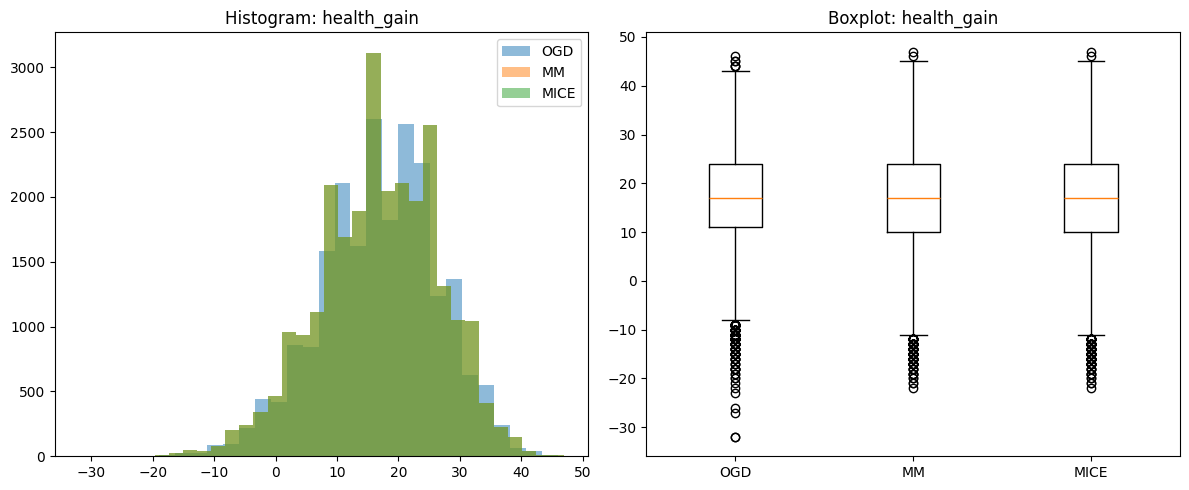

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


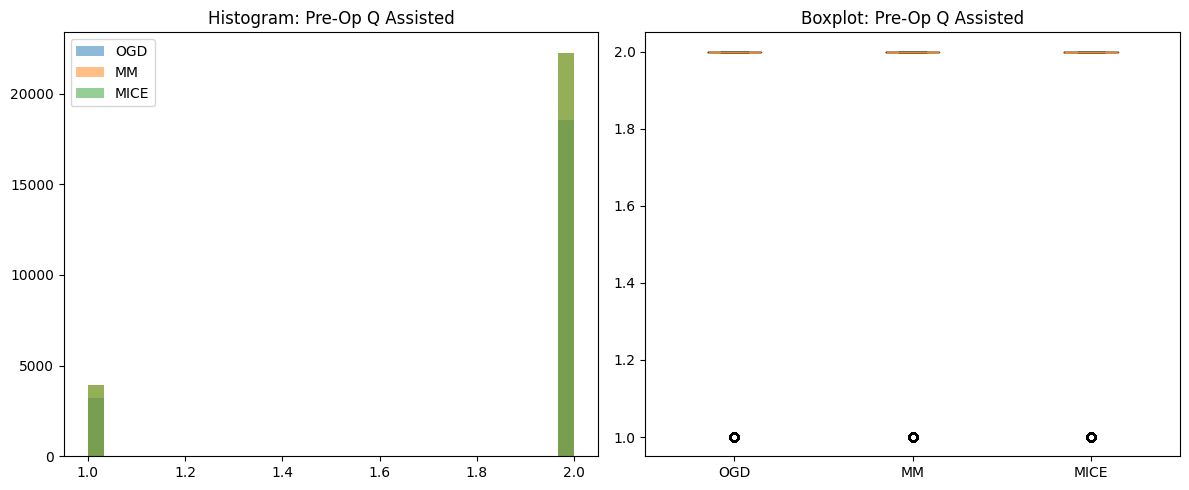

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


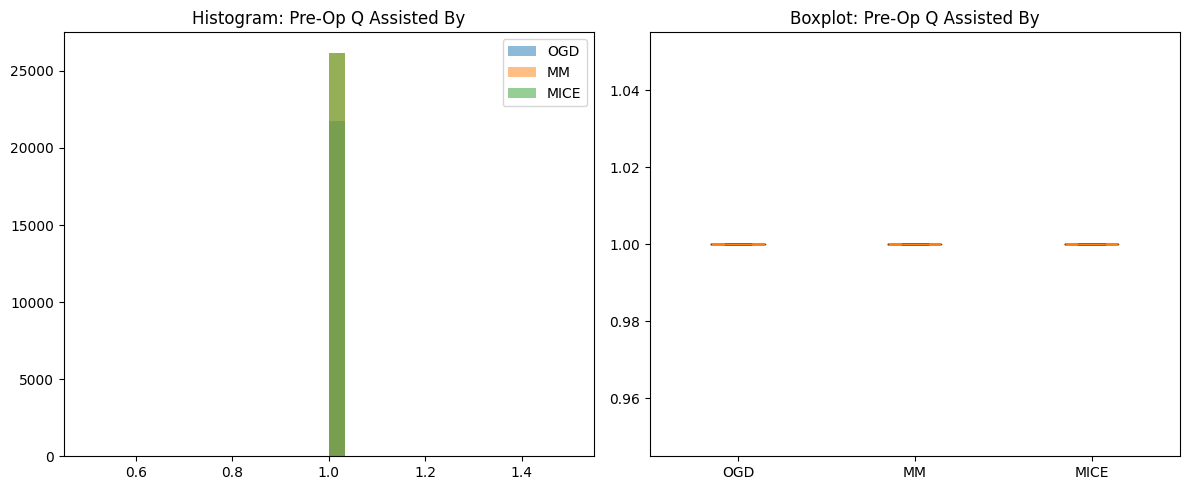

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


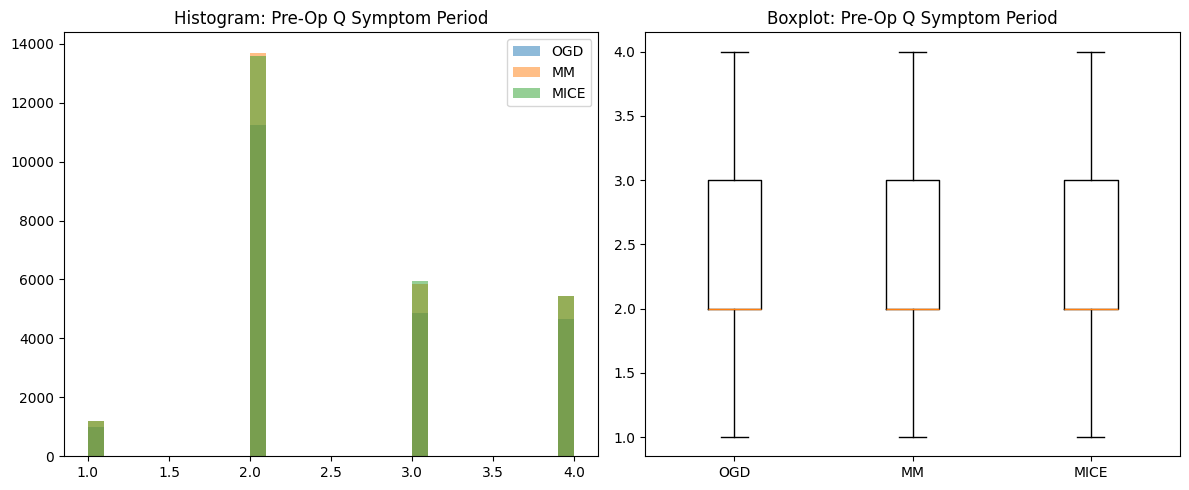

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


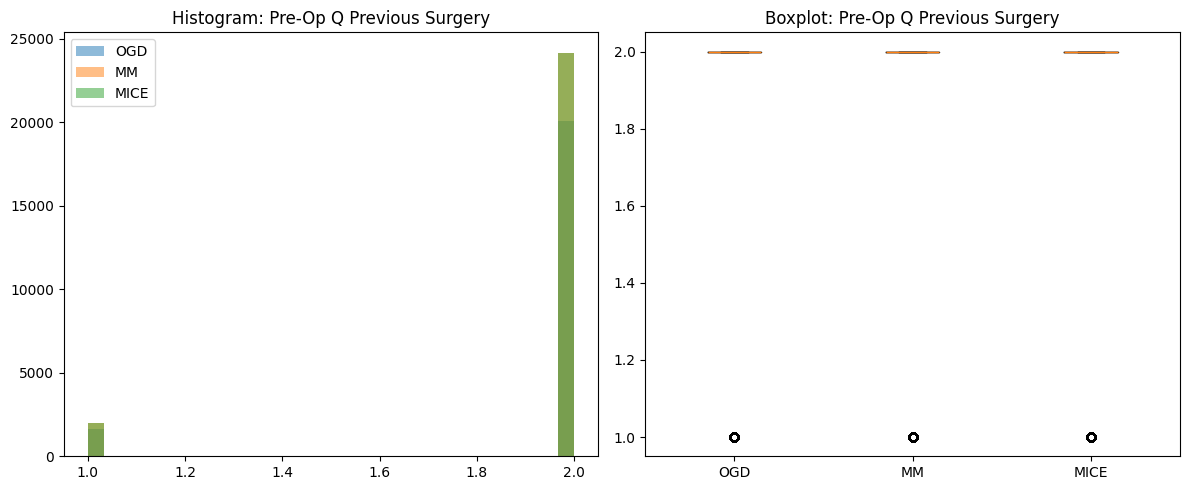

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


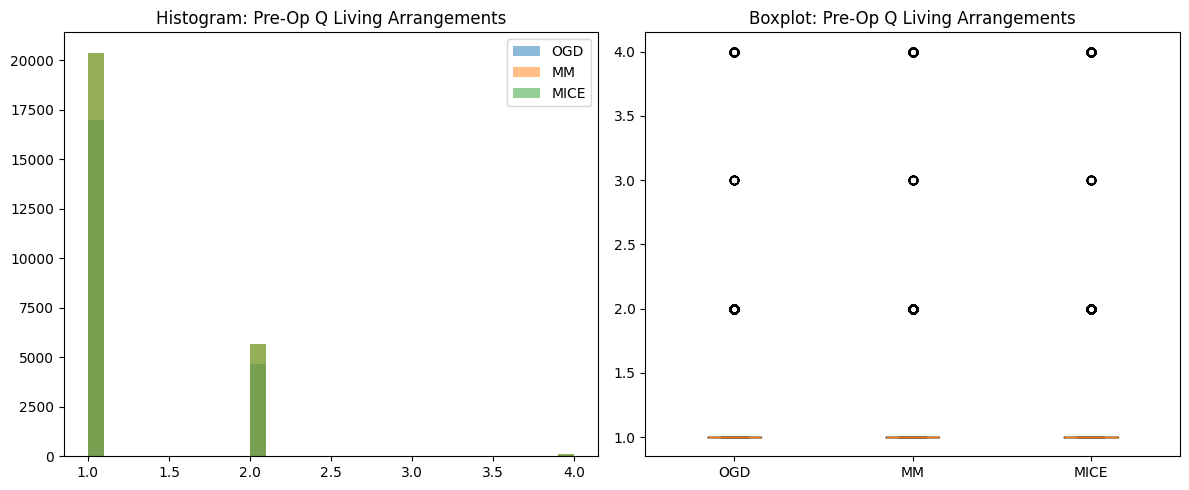

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


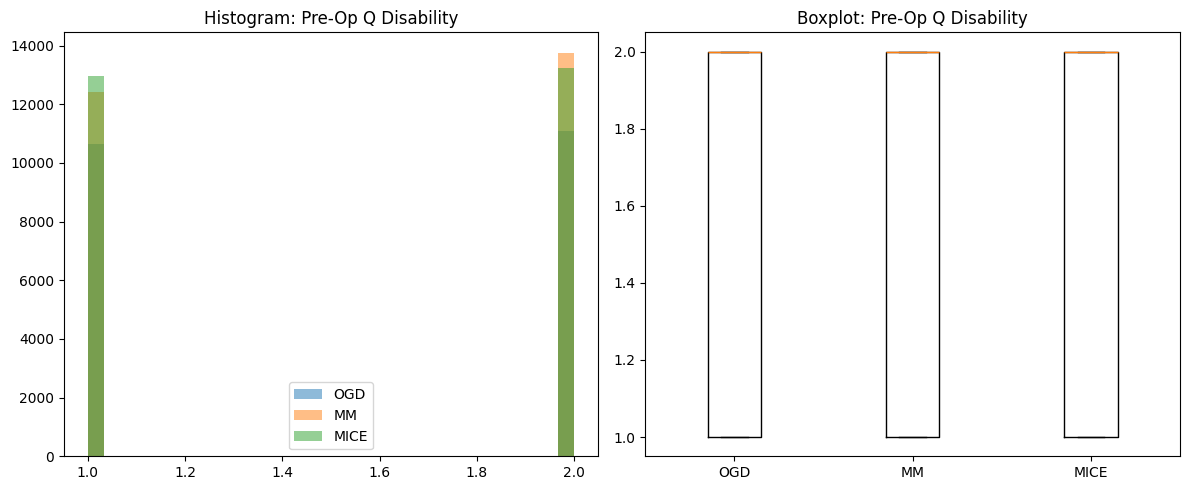

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


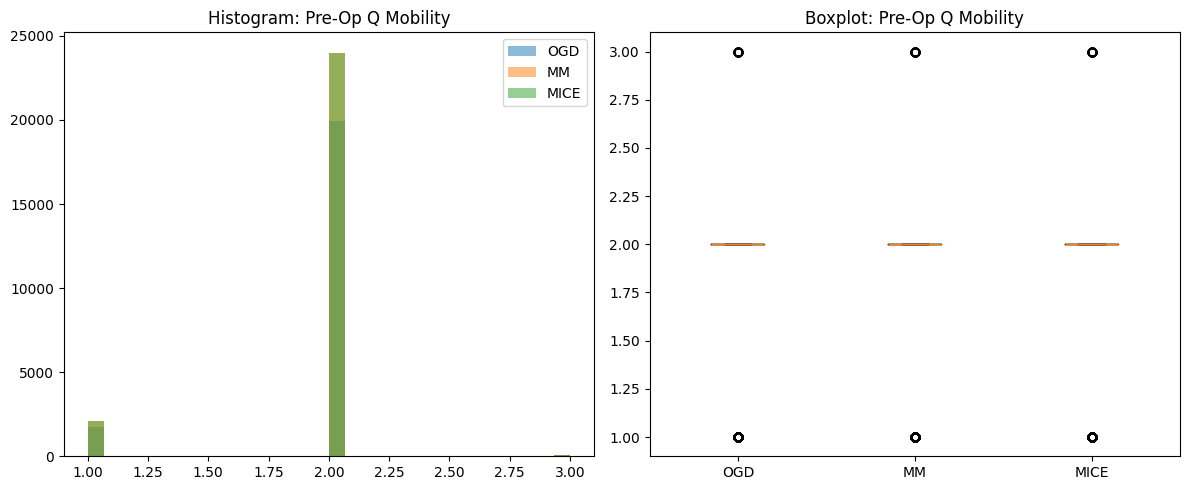

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


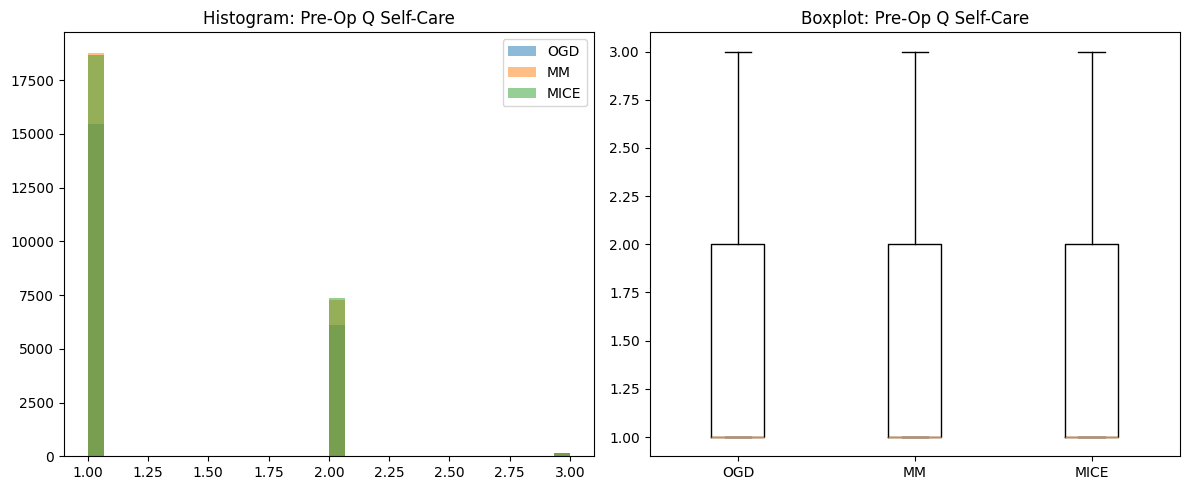

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


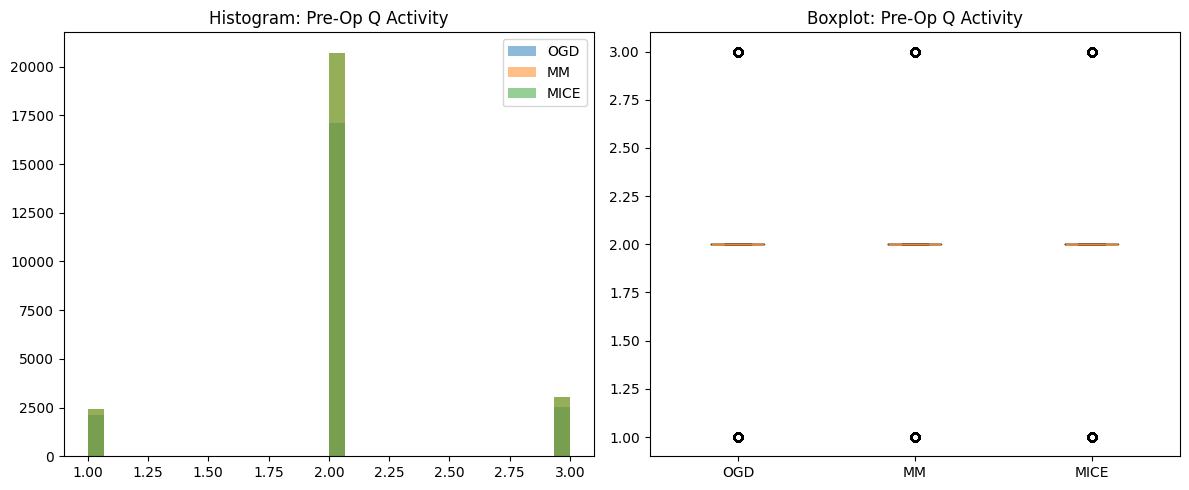

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


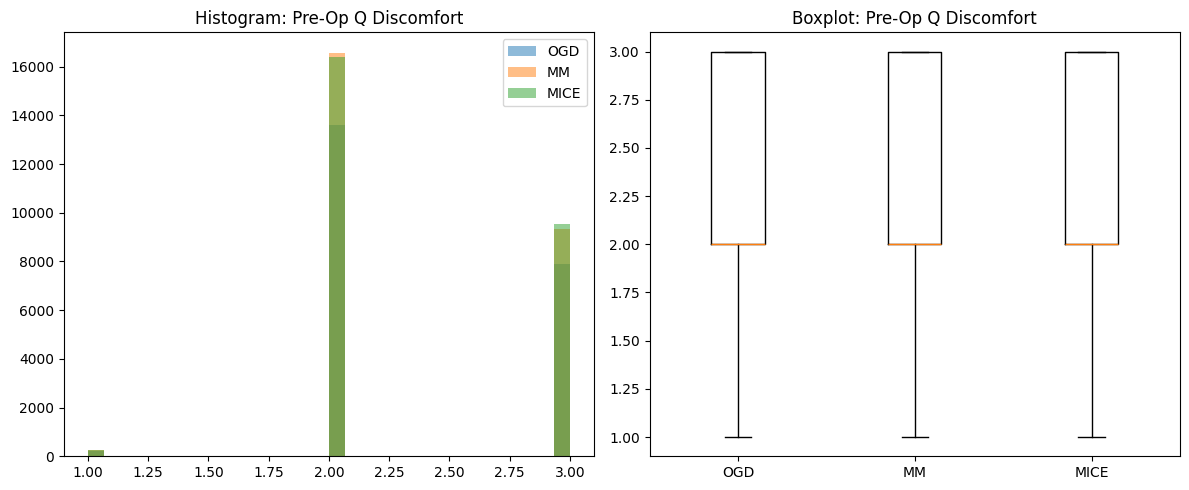

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


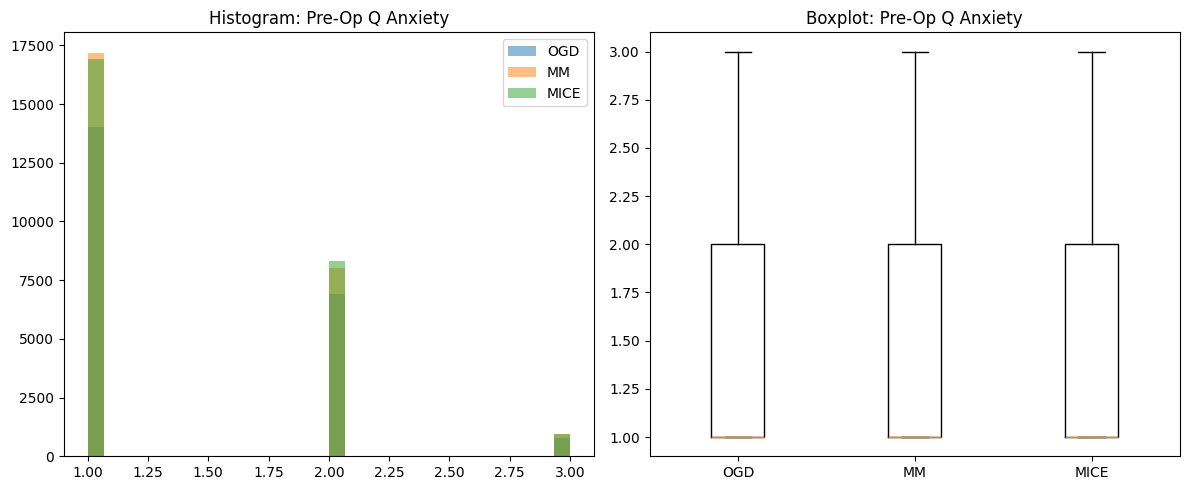

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


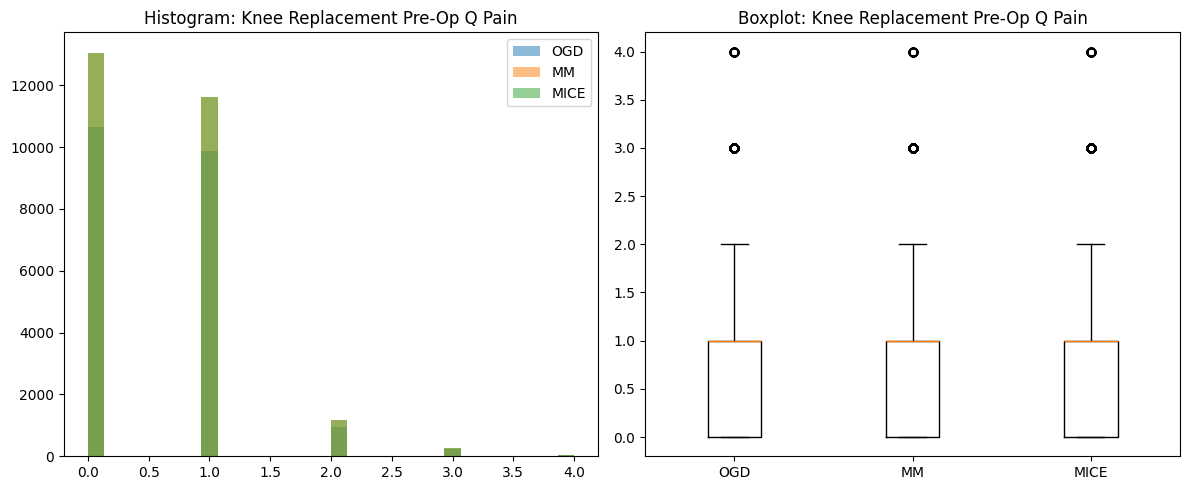

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


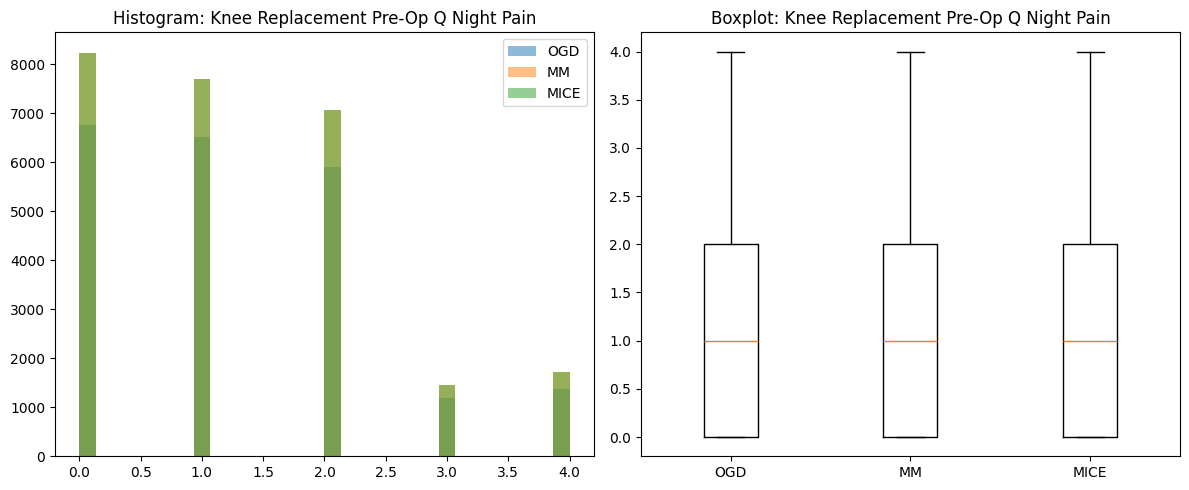

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


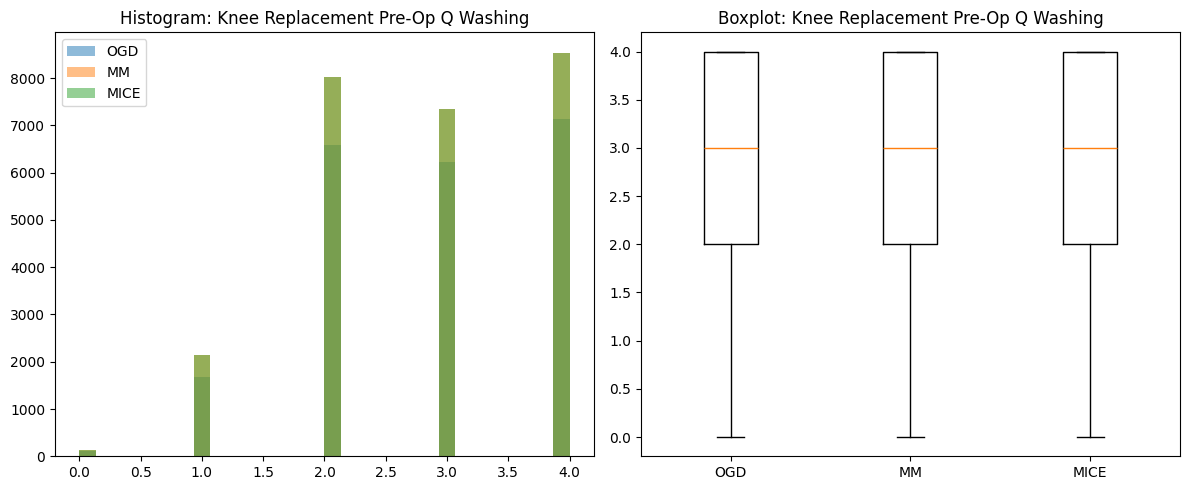

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


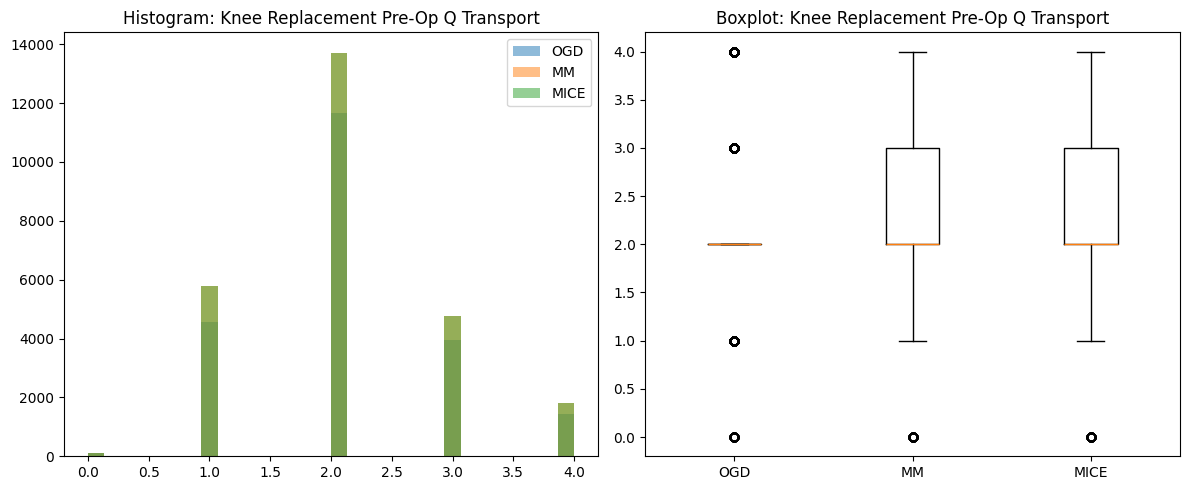

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


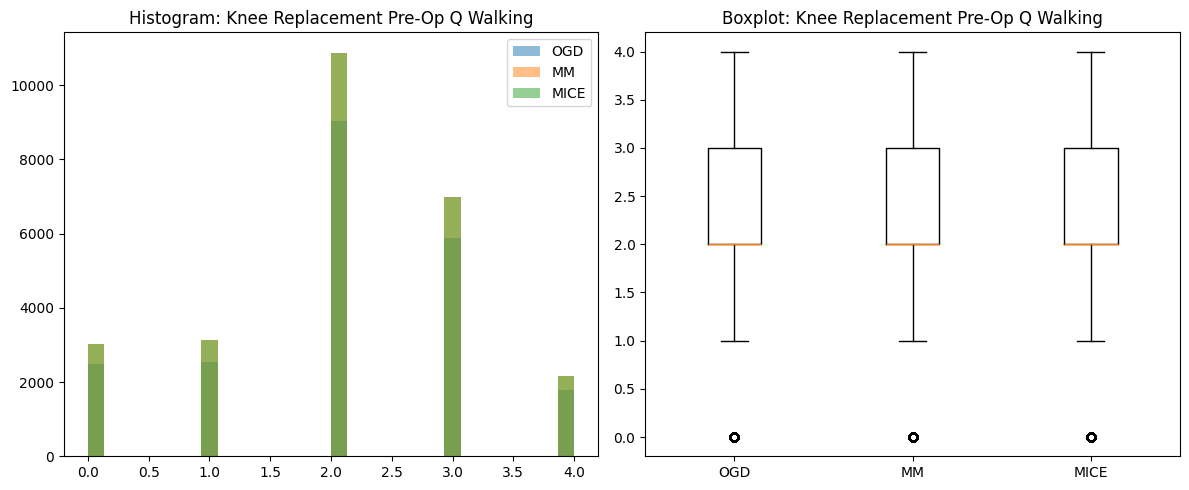

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


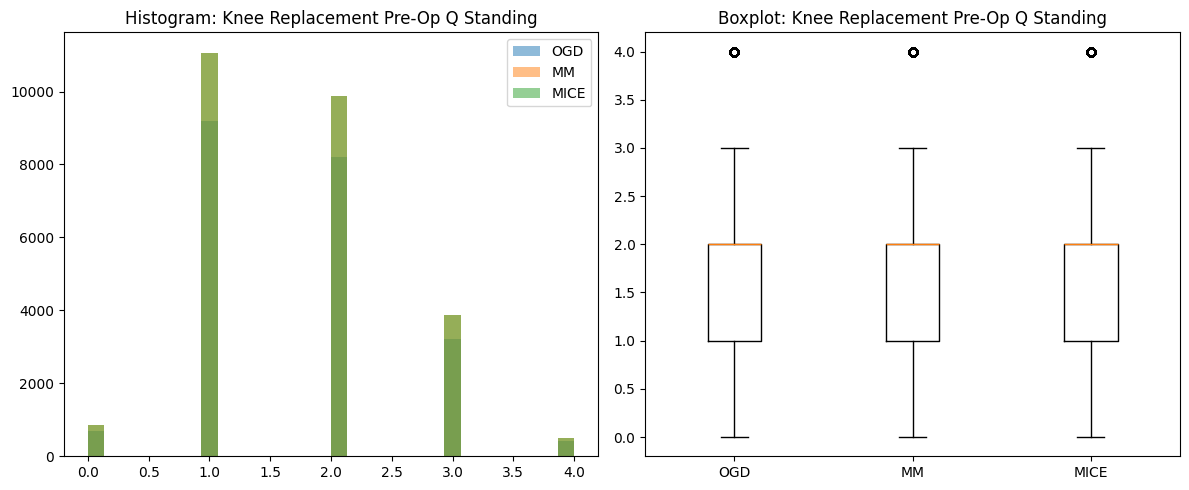

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


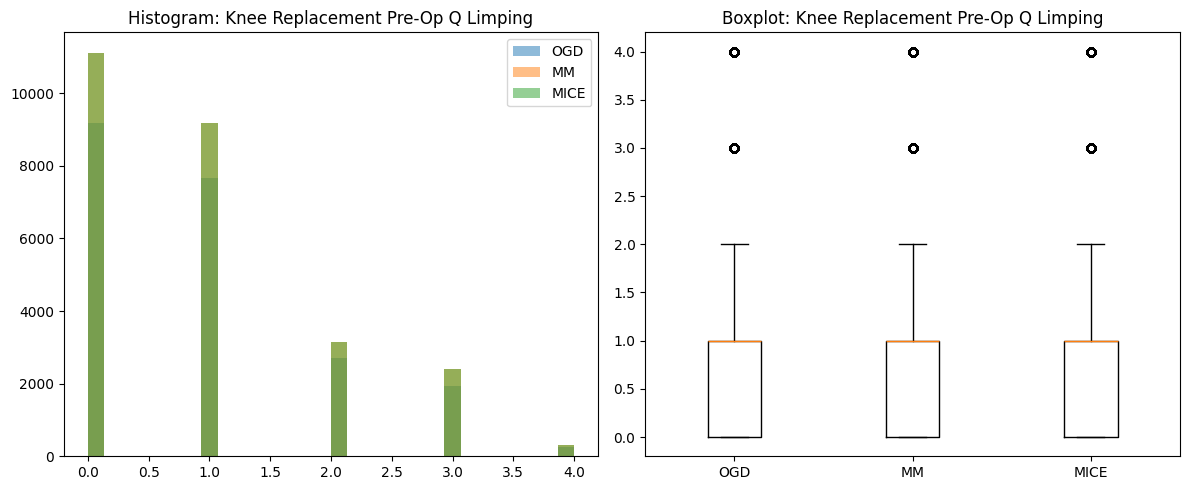

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


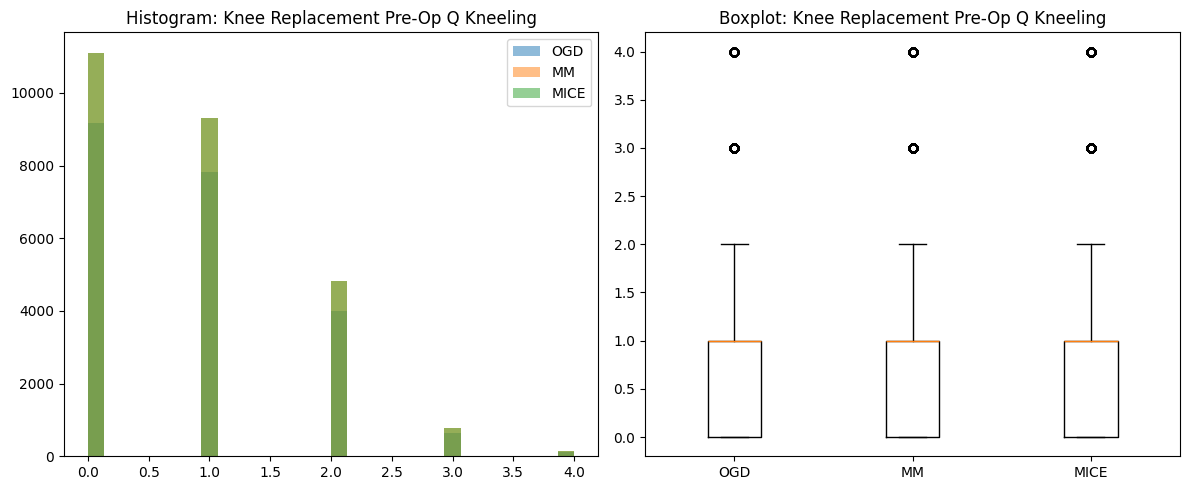

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


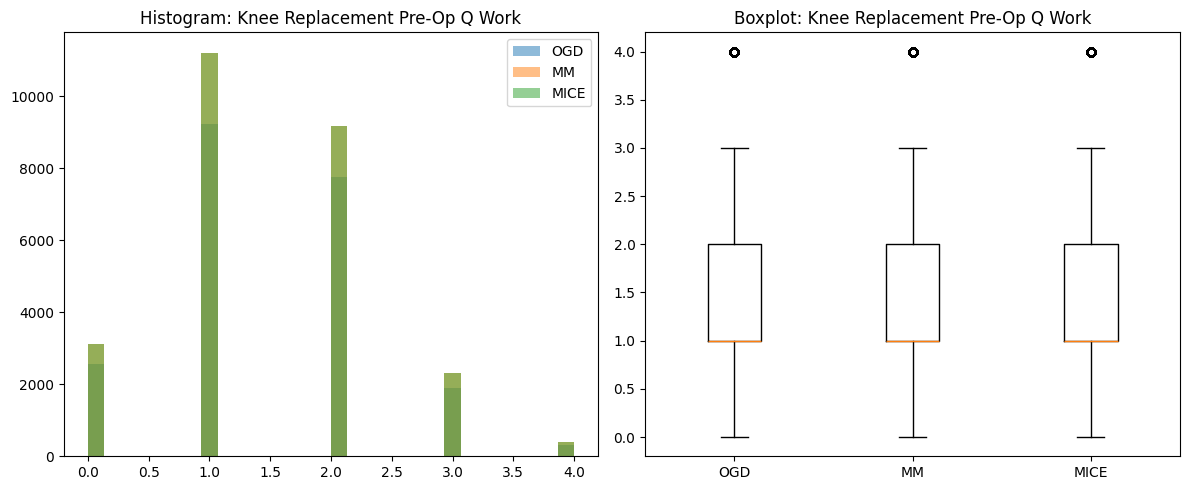

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


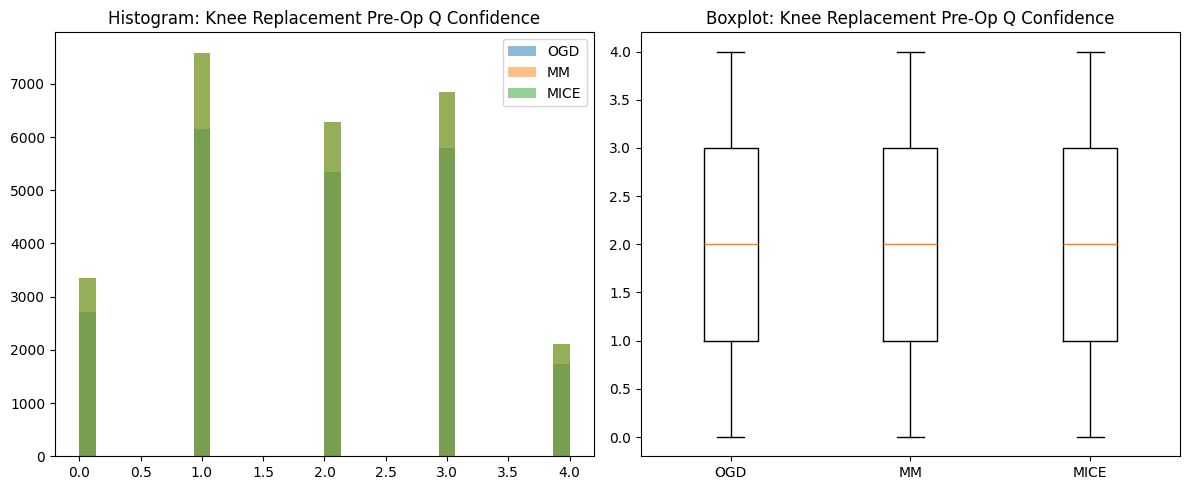

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


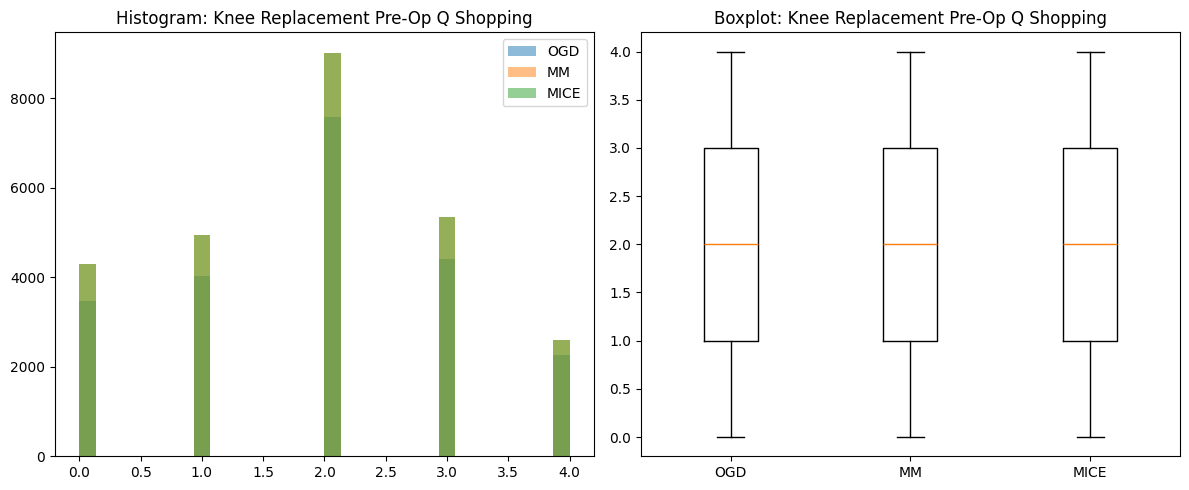

C:\Users\jkrin\AppData\Local\Temp\ipykernel_12964\590080409.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])


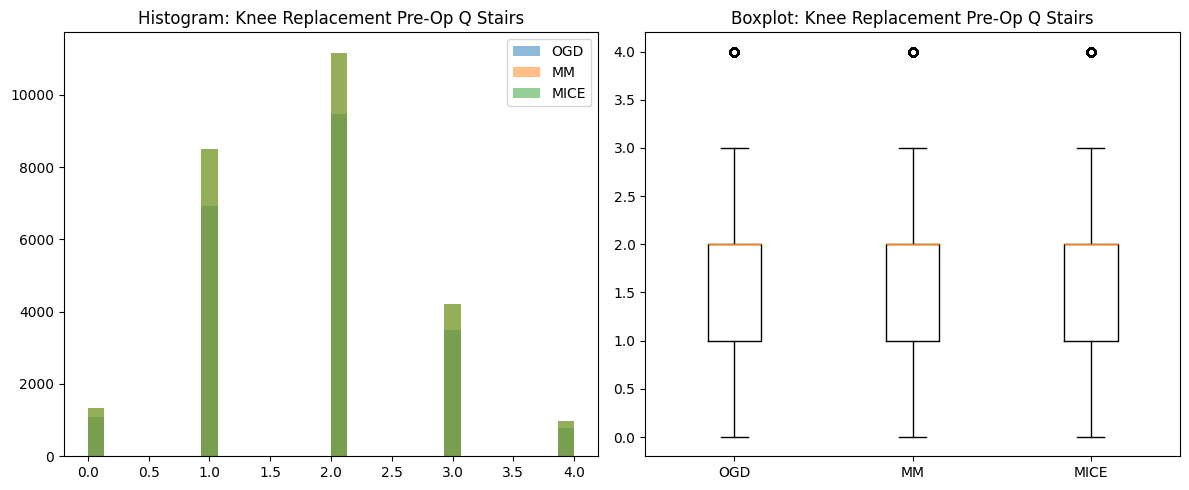

In [ ]:

import polars as pl
import matplotlib.pyplot as plt

# Key numeric variables
key_numeric_vars = [
    'health_gain',
    'Pre-Op Q Assisted','Pre-Op Q Assisted By','Pre-Op Q Symptom Period',
    'Pre-Op Q Previous Surgery','Pre-Op Q Living Arrangements','Pre-Op Q Disability',
    'Pre-Op Q Mobility','Pre-Op Q Self-Care','Pre-Op Q Activity',
    'Pre-Op Q Discomfort','Pre-Op Q Anxiety',
    'Knee Replacement Pre-Op Q Pain','Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing','Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking','Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping','Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work','Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping','Knee Replacement Pre-Op Q Stairs'
]

# --- Summary statistics table ---
stats_manu = df_ogd.select(
    [pl.col(v).mean().alias(f"{v}_mean_manu") for v in key_numeric_vars] +
    [pl.col(v).median().alias(f"{v}_median_manu") for v in key_numeric_vars] +
    [pl.col(v).std().alias(f"{v}_std_manu") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.25).alias(f"{v}_q25_manu") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.75).alias(f"{v}_q75_manu") for v in key_numeric_vars]
)

stats_mm = df_mm.select(
    [pl.col(v).mean().alias(f"{v}_mean_mm") for v in key_numeric_vars] +
    [pl.col(v).median().alias(f"{v}_median_mm") for v in key_numeric_vars] +
    [pl.col(v).std().alias(f"{v}_std_mm") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.25).alias(f"{v}_q25_mm") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.75).alias(f"{v}_q75_mm") for v in key_numeric_vars]
)

stats_mice = df_mice.select(
    [pl.col(v).mean().alias(f"{v}_mean_mice") for v in key_numeric_vars] +
    [pl.col(v).median().alias(f"{v}_median_mice") for v in key_numeric_vars] +
    [pl.col(v).std().alias(f"{v}_std_mice") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.25).alias(f"{v}_q25_mice") for v in key_numeric_vars] +
    [pl.col(v).quantile(0.75).alias(f"{v}_q75_mice") for v in key_numeric_vars]
)

print("=== Summary Statistics: OGD ===")
print(stats_manu)

print("\n=== Summary Statistics: MM ===")
print(stats_mm)

print("\n=== Summary Statistics: MICE ===")
print(stats_mice)


# --- Visual comparison: histograms + boxplots ---
for col in key_numeric_vars:
    ogd_vals = df_ogd[col].drop_nulls().to_numpy()
    mm_vals = df_mm[col].drop_nulls().to_numpy()    
    mice_vals = df_mice[col].drop_nulls().to_numpy()

    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(ogd_vals, bins=30, alpha=0.5, label="OGD")
    plt.hist(mm_vals, bins=30, alpha=0.5, label="MM")
    plt.hist(mice_vals, bins=30, alpha=0.5, label="MICE")
    plt.title(f"Histogram: {col}")
    plt.legend()

    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot([ogd_vals, mm_vals, mice_vals], labels=["OGD", "MM", "MICE"])
    plt.title(f"Boxplot: {col}")

    plt.tight_layout()
    plt.show()
